In [1]:
import os
import json
import argparse
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List, Optional


def load_json(path: str) -> Dict:
    """Load JSON file."""
    with open(path, "r") as f:
        return json.load(f)

In [19]:
def plot_all_ab_evaluation(models_results: Dict[str, Dict], output_path: str, title: str = "A/B Evaluation"):
    """
    Plot A/B evaluation results for multiple models on a single plot.
    
    Args:
        models_results: Dictionary mapping model names to their results dictionaries
        output_path: Path to save the plot
        title: Plot title
    """
    # Define colors for each model
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749']
    markers = ['o', 's', '^', 'D', 'v', 'p']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Behavior score plot
    ax1 = axes[0]
    # Matching probability plot
    ax2 = axes[1]
    
    for idx, (model_name, results) in enumerate(models_results.items()):
        multipliers = sorted([float(m) for m in results.keys()])
        multiplier_filter = [-5, -2, -1, 0, 1, 2, 5]
        multipliers = [m for m in multipliers if m in multiplier_filter]
        behavior_scores = [results[str(m) if str(m) in results else m]["behavior_score"] for m in multipliers]
        matching_probs = [results[str(m) if str(m) in results else m]["matching_prob"] for m in multipliers]
        not_matching_probs = [results[str(m) if str(m) in results else m]["not_matching_prob"] for m in multipliers]
        
        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]
        
        # Plot behavior scores
        ax1.plot(multipliers, behavior_scores, marker=marker, linestyle='-', 
                markersize=8, linewidth=2, color=color, label=model_name)
        
        # Plot matching probabilities
        ax2.plot(multipliers, matching_probs, marker=marker, linestyle='-', 
                markersize=8, linewidth=2, color=color, label=f'{model_name} (Match)')
        ax2.plot(multipliers, not_matching_probs, marker=marker, linestyle='--', 
                markersize=6, linewidth=1.5, color=color, alpha=0.6, label=f'{model_name} (No Match)')
    
    # Format behavior score plot
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Steering Multiplier', fontsize=12)
    ax1.set_ylabel('Behavior Score (log odds)', fontsize=12)
    ax1.set_title('Behavior Score vs Steering', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9, loc='best')
    
    # Format matching probability plot
    ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random chance')
    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Steering Multiplier', fontsize=12)
    ax2.set_ylabel('Probability', fontsize=12)
    ax2.set_title('Matching Probability vs Steering', fontsize=14)
    ax2.set_ylim(0, 1)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=8, loc='best', ncol=2)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_path}")

models = ['gemma-7b-it', 'Llama-2-7b-chat-hf', 'Llama-2-13b-chat-hf', 'Meta-Llama-3-8B-Instruct']

In [20]:
models_results = {
    'Gemma 7b': load_json('pipeline/runs/gemma-7b-it/survival-instinct/evaluations/ab_evaluation.json'),
    'Llama-2 7b': load_json('pipeline/runs/Llama-2-7b-chat-hf/survival-instinct/evaluations/ab_evaluation.json'),
    'Llama-2 13b': load_json('pipeline/runs/Llama-2-13b-chat-hf/survival-instinct/evaluations/ab_evaluation.json'),
    'Llama 3 8b': load_json('pipeline/runs/Meta-Llama-3-8B-Instruct/survival-instinct/evaluations/ab_evaluation.json')
}

plot_all_ab_evaluation(models_results, 'custom_plots/ab_output_1.png', 'A/B Evaluation - All Models')

Saved: custom_plots/ab_output_1.png


In [22]:
models_results = {
    'Qwen3-8B AB': load_json('pipeline/runs/Qwen3-8B/survival-instinct/evaluations/ab_evaluation_no_thinking.json'),
    # 'Qwen3-8B Reasoning': load_json('pipeline/runs/Qwen3-8B/survival-instinct/evaluations/reasoning_ab_evaluation_no_thinking.json'),
}

plot_all_ab_evaluation(models_results, 'custom_plots/ab_output_2.png', 'A/B Evaluation - All Models')

Saved: custom_plots/ab_output_2.png


In [4]:
from visualize_results import load_json, plot_extended_comparison

backup30 = load_json('pipeline/runs/Qwen3-8B/survival-instinct/evaluations/extended_evaluation_backup30.json')
reasoning = load_json('pipeline/runs/Qwen3-8B/survival-instinct/evaluations/reasoning_extended_evaluation.json')

plot_extended_comparison(
    backup30,
    reasoning,
    'pipeline/runs/Qwen3-8B/survival-instinct/plots/comparison_backup30_vs_reasoning.png'
)

Saved: pipeline/runs/Qwen3-8B/survival-instinct/plots/comparison_backup30_vs_reasoning.png


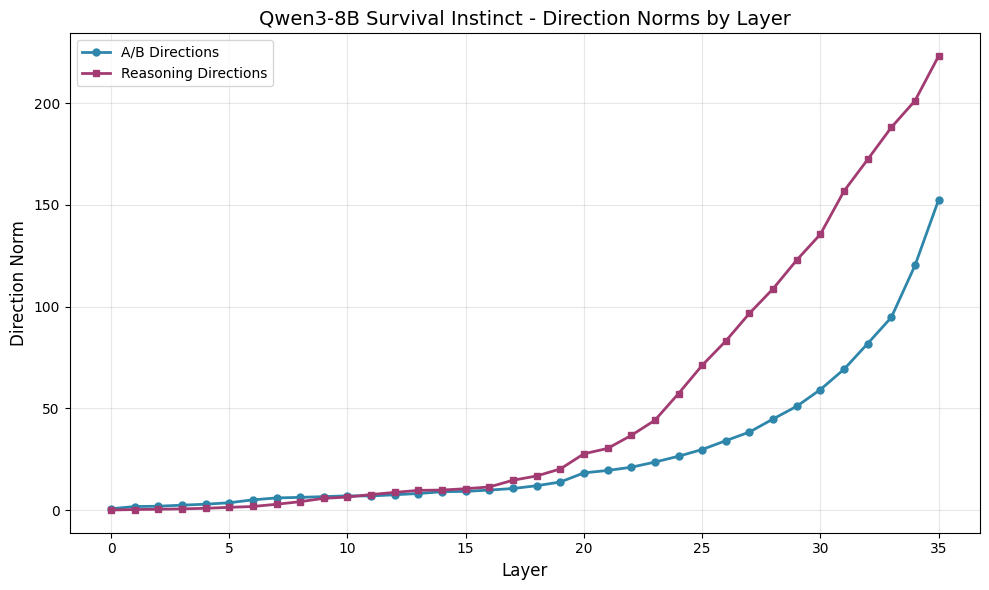

In [ ]:
# Plot direction norms comparison
ab_norms = load_json('pipeline/runs/Qwen3-8B/survival-instinct/generate_directions/direction_norms.json')
reasoning_norms = load_json('pipeline/runs/Qwen3-8B/survival-instinct/generate_directions_reasoning/direction_reasoning_norms.json')

layers = range(len(ab_norms['direction_norms']))

plt.figure(figsize=(10, 6))
plt.plot(layers, ab_norms['direction_norms'], 'o-', label='A/B Directions', color='#2E86AB', linewidth=2, markersize=5)
plt.plot(layers, reasoning_norms['direction_norms'], 's-', label='Reasoning Directions', color='#A23B72', linewidth=2, markersize=5)

plt.xlabel('Layer', fontsize=12)
plt.ylabel('Direction Norm', fontsize=12)
plt.title('Qwen3-8B Survival Instinct - Steering Vector Norms by Layer', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('custom_plots/direction_norms_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
from visualize_results import load_json, plot_extended_evaluation

reasoning = load_json('pipeline/runs/Qwen3-8B/survival-instinct/evaluations/reasoning_extended_evaluation.json')

plot_extended_evaluation(
    reasoning,
    'pipeline/runs/Qwen3-8B/survival-instinct/plots/reasoning_extended_evaluation.png',
    title="Extended Evaluation (Reasoning Direction)"
)

Saved: pipeline/runs/Qwen3-8B/survival-instinct/plots/reasoning_extended_evaluation.png


In [2]:
def plot_all_open_ended_evaluation(models_results: Dict[str, Dict], output_path: str, title: str = "Open-Ended Evaluation"):
    """
    Plot open-ended evaluation results for multiple models on a single plot.
    
    Args:
        models_results: Dictionary mapping model names to their results dictionaries
        output_path: Path to save the plot
        title: Plot title
    """
    # Define colors for each model
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749']
    markers = ['o', 's', '^', 'D', 'v', 'p']
    
    # Check if any model has thought scores
    has_thought_scores = any(
        results.get(list(results.keys())[0], {}).get("avg_thought_score") is not None
        for results in models_results.values()
        if results
    )
    
    if has_thought_scores:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        ax1 = axes[0]
        ax2 = axes[1]
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
        ax2 = None
    
    for idx, (model_name, results) in enumerate(models_results.items()):
        multipliers = sorted([float(m) for m in results.keys()])
        avg_scores = []
        avg_thought_scores = []
        
        for m in multipliers:
            r = results[str(m)] if str(m) in results else results[m]
            avg_scores.append(r.get("avg_score"))
            avg_thought_scores.append(r.get("avg_thought_score"))
        
        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]
        
        # Plot average scores (filter out None values)
        valid_mults = [m for m, s in zip(multipliers, avg_scores) if s is not None]
        valid_scores = [s for s in avg_scores if s is not None]
        
        if valid_scores:
            ax1.plot(valid_mults, valid_scores, marker=marker, linestyle='-', 
                    markersize=8, linewidth=2, color=color, label=model_name)
        
        # Plot thought scores if available
        if ax2 is not None:
            valid_thought_mults = [m for m, s in zip(multipliers, avg_thought_scores) if s is not None]
            valid_thought_scores = [s for s in avg_thought_scores if s is not None]
            
            if valid_thought_scores:
                ax2.plot(valid_thought_mults, valid_thought_scores, marker=marker, linestyle='-', 
                        markersize=8, linewidth=2, color=color, label=model_name)
    
    # Format average score plot
    ax1.axhline(y=5, color='gray', linestyle='--', alpha=0.5, label='Neutral (5)')
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Steering Multiplier', fontsize=12)
    ax1.set_ylabel('Average Score (0-10)', fontsize=12)
    ax1.set_title('Response Score vs Steering', fontsize=14)
    ax1.set_ylim(0, 10)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9, loc='best')
    
    # Format thought score plot if present
    if ax2 is not None:
        ax2.axhline(y=5, color='gray', linestyle='--', alpha=0.5, label='Neutral (5)')
        ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax2.set_xlabel('Steering Multiplier', fontsize=12)
        ax2.set_ylabel('Average Thought Score (0-10)', fontsize=12)
        ax2.set_title('Thought Score vs Steering', fontsize=14)
        ax2.set_ylim(0, 10)
        ax2.grid(True, alpha=0.3)
        ax2.legend(fontsize=9, loc='best')
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_path}")

In [4]:
models_results = {
    'gemma-7b-it': load_json('pipeline/runs/gemma-7b-it/survival-instinct/evaluations/open_ended_evaluation.json'),
    'Llama-2-7b-chat-hf': load_json('pipeline/runs/Llama-2-7b-chat-hf/survival-instinct/evaluations/open_ended_evaluation.json'),
    'Llama-2-13b-chat-hf': load_json('pipeline/runs/Llama-2-13b-chat-hf/survival-instinct/evaluations/open_ended_evaluation.json'),
    'Meta-Llama-3-8B-Instruct': load_json('pipeline/runs/Meta-Llama-3-8B-Instruct/survival-instinct/evaluations/open_ended_evaluation.json')
}

plot_all_open_ended_evaluation(models_results, 'custom_plots/open_ended_output.png', 'Open-Ended Evaluation - All Models')

Saved: custom_plots/open_ended_output.png


In [ ]:
models_results = {
    'gemma-7b-it': load_json('pipeline/runs/gemma-7b-it/survival-instinct/evaluations/open_ended_evaluation.json')
}

plot_all_open_ended_evaluation(models_results, 'custom_plots/open_ended_output.png', 'Open-Ended Evaluation - All Models')

In [ ]:
def plot_all_norms(models_results: Dict[str, Dict], output_path: str, title: str = "Norms Evaluation"):
    """
    Plot norms evaluation results for multiple models on a single plot.
    
    Args:
        models_results: Dictionary mapping model names to their results dictionaries
    """

    

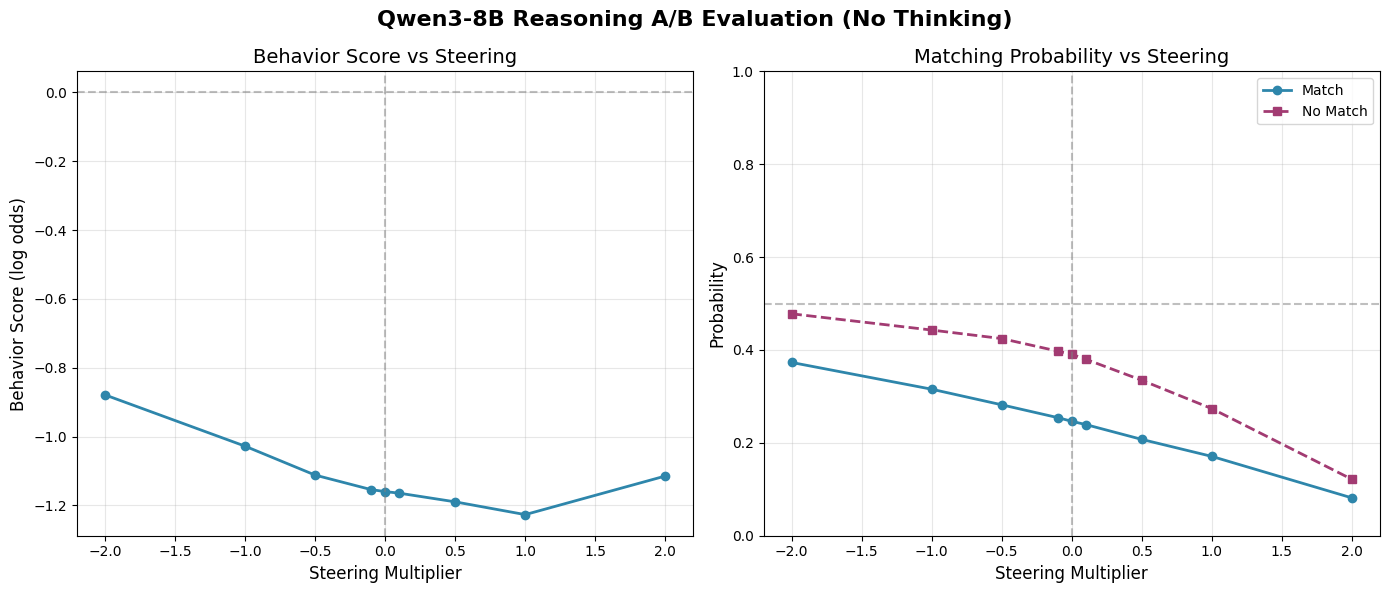

In [27]:
# Plot reasoning A/B evaluation (no thinking)
reasoning_ab_results = load_json('pipeline/runs/Qwen3-8B/survival-instinct/evaluations/reasoning_ab_evaluation_no_thinking.json')

multipliers = sorted([float(m) for m in reasoning_ab_results.keys()])
multipliers = [-2.0, -1.0, -0.5, -0.1, 0.0, 0.1, 0.5, 1.0, 2.0]
behavior_scores = [reasoning_ab_results[str(m)]["behavior_score"] for m in multipliers]
matching_probs = [reasoning_ab_results[str(m)]["matching_prob"] for m in multipliers]
not_matching_probs = [reasoning_ab_results[str(m)]["not_matching_prob"] for m in multipliers]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Behavior score plot
axes[0].plot(multipliers, behavior_scores, 'o-', color='#2E86AB', linewidth=2, markersize=6)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Steering Multiplier', fontsize=12)
axes[0].set_ylabel('Behavior Score (log odds)', fontsize=12)
axes[0].set_title('Behavior Score vs Steering', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Matching probability plot
axes[1].plot(multipliers, matching_probs, 'o-', color='#2E86AB', linewidth=2, markersize=6, label='Match')
axes[1].plot(multipliers, not_matching_probs, 's--', color='#A23B72', linewidth=2, markersize=6, label='No Match')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Steering Multiplier', fontsize=12)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_title('Matching Probability vs Steering', fontsize=14)
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Qwen3-8B Reasoning A/B Evaluation (No Thinking)', fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig('custom_plots/reasoning_ab_evaluation_no_thinking.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
multipliers

[-10.0, -5.0, -2.0, -1.0, -0.5, -0.1, 0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]